<a href="https://colab.research.google.com/github/Hadeed07/FlyRank-ML/blob/main/work/notebooks/w03_feature_leakage_check.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-05 — Feature Vector and Leakage/Privacy Check

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Hadeed07/FlyRank-ML/blob/main/work/notebooks/w03_feature_leakage_check.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Build the feature vector

*Code that actually builds it — engineered features, categorical handling, fills.*

In [40]:
!git clone https://github.com/Hadeed07/FlyRank-ML.git
import pandas as pd

fatal: destination path 'FlyRank-ML' already exists and is not an empty directory.


In [41]:
df = pd.read_csv('/content/FlyRank-ML/data/raw/content_refresh_anonymized.csv')
print(df.shape)
print(df['content_id'].nunique())   # should match row count if truly 1 row per page
print(df['client_id'].nunique())    # should be 32
df.head()

(30000, 44)
30000
32


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [42]:
df.columns.tolist()

['content_id',
 'client_id',
 'search_volume',
 'competition',
 'competition_level',
 'cpc',
 'content_type',
 'main_intent',
 'word_count',
 'char_count',
 'provider_used',
 'model_used',
 'impressions_90d',
 'clicks_90d',
 'pageviews_90d',
 'sessions_90d',
 'users_90d',
 'engaged_sessions_90d',
 'ai_sessions_90d',
 'scroll_events_90d',
 'days_with_impressions',
 'days_with_sessions',
 'impressions_last_30d',
 'clicks_last_30d',
 'sessions_last_30d',
 'impressions_prev_30d',
 'clicks_prev_30d',
 'sessions_prev_30d',
 'content_age_days',
 'age_tier',
 'age_tier_order',
 'days_since_last_update',
 'freshness_tier',
 'word_count_tier',
 'char_count_tier',
 'ctr',
 'avg_position',
 'engagement_rate',
 'scroll_rate',
 'ai_traffic_pct',
 'impression_tier',
 'position_tier',
 'trend_direction',
 'trend_pct']

Checking the categorical columns and their unique values - to figure out whether the one hot encoding is feasible.

In [43]:
categorical_cols = ['content_type', 'main_intent', 'provider_used', 'model_used',
                     'age_tier', 'freshness_tier', 'competition_level']
for col in categorical_cols:
    print(col, df[col].nunique())

content_type 3
main_intent 4
provider_used 2
model_used 5
age_tier 4
freshness_tier 4
competition_level 3


In [44]:
df.isnull().sum()

,0
content_id,0
client_id,0
search_volume,2468
competition,2468
competition_level,2610
cpc,2468
content_type,0
main_intent,2374
word_count,7699
char_count,7699


## 2. Feature notes (meaning, missing, categorical, available-when?)

*For each feature: what it means, how missing values are handled, and whether it exists BEFORE the moment you predict.*

The `search_volume` can be zero because it is the estimated number given by Google to see how freqeuently a word or a phrase is typed into a search engine each month. Zero `search_volume` means that the word is never being typed into search engine or it can be niche or new topics that don't have enough search traffic.

The `main_intent` is the intent why a query is being searched in the first place. This can also be zero in case if someone typed the ambiguous query like a single word or random words or nonsensical queries.


The same reasons is also apply to `cpc` and `competition`. If the query is ambiguous then the cost per click and the competition both are low.

As it is established that the `search_volume` determines the `main_intent`, `cpc`, `competition` for the same reason: no search volume means no competition data and no cpc.

But it doesn't entail that `model_used` and `provider_used` can be zero too, which give the information about which statistical or AI model generate the output and what is the source of data (youtube, google ads, bing etc)


`trend_pct` also have some missing values while `trend_direction` has none, as it is still a label (assign by a rule) This issue goes back to 5-class vs 3-class classification problem. If `new`/`flat` really are zero-history states (no prior data to compare against), then there would be no percentage change to compute those rows, this could explain why `trend_pct` has missing values.

The `trend_pct`'s every single missing row accounted by `new`/`flat` as 2,236+ 1,152 = 3388. That's a confirmation. These rows are the structural artifacts and it is safe to exclude them.

In [45]:
print(df[df['trend_pct'].isnull()]['trend_direction'].value_counts())

trend_direction
new     2236
flat    1152
Name: count, dtype: int64


Here for search volume, the missing values can be safely replaced by zero since `search_volume` has some meaning associated with zero.

In [46]:
df['search_volume'].isna().sum()

np.int64(2468)

Here the missingness is concentrated only in keyword articles `content_type`, for word counts. Possibly a subset like image-only or template driven pages within that category aren't clear and can't be verified from available fields.

The ground truth must required.

In [47]:
print(df[df['word_count'].isnull()]['content_type'].value_counts())
print(df['content_type'].value_counts())  # compare against the full distribution

content_type
keyword article    7699
Name: count, dtype: int64
content_type
keyword article       27207
feedly article         2096
comparison article      697
Name: count, dtype: int64


<Axes: >

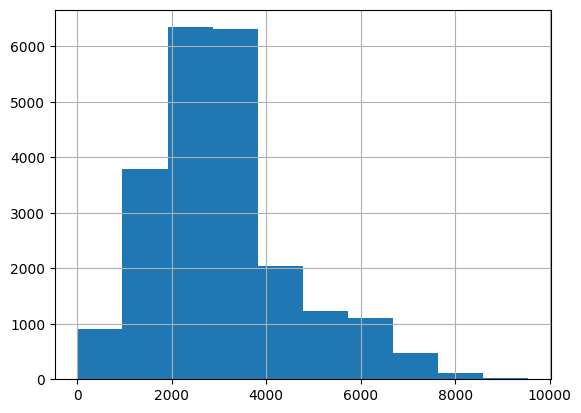

In [48]:
df['word_count'].hist()

In [49]:
# check the relationship on rows where both are known
known_both = df[df['word_count'].notnull() & df['char_count'].notnull()]
print((known_both['char_count'] / known_both['word_count']).describe())

count    22301.000000
mean         6.671307
std          1.278731
min          5.000000
25%          6.337390
50%          6.573441
75%          6.840967
max         53.296429
dtype: float64


Check where words are missing and where the char are missing. The output shows both words and chars are missing together and from the previous check, it is confirmed that their missing values are `keyword article` type.

Missingness is only concentrated in `keyword article` content type, it affects only 28% of that type yet the root cause is unconfirmed.

In [50]:
only_word_missing = df['word_count'].isnull() & df['char_count'].notnull()
only_char_missing = df['char_count'].isnull() & df['word_count'].notnull()
print(only_word_missing.sum(), only_char_missing.sum())

0 0


In [51]:
print(df['word_count'].mean(), df['word_count'].median())
print(df['char_count'].mean(), df['char_count'].median())

3107.760324649119 2877.0
20665.27783507466 19116.0


Both `word_count` and `char_count` are right skewed and replacing the missing values with median is a handy choice.

`provider_used` and `model_used` compared with each other to see when one of them is zero or both are zero.
It completley makes sense either way.

In [52]:
both_missing = df['provider_used'].isnull() & df['model_used'].isnull()
only_provider_missing = df['provider_used'].isnull() & df['model_used'].notnull()
only_model_missing = df['model_used'].isnull() & df['provider_used'].notnull()


print("Both missing:", both_missing.sum())
print("Only provider missing (model_used present):", only_provider_missing.sum())
print("Only model missing (provider_used present):", only_model_missing.sum())

Both missing: 5732
Only provider missing (model_used present): 15706
Only model missing (provider_used present): 1


In [53]:
df['model_used'].value_counts()

,count
model_used,
gemini-3-flash-preview,13271
gpt-4o-mini,4981
gemini-2.5-flash,3665
gpt-5-mini,1598
unknown,752


In [54]:
df['provider_used'].value_counts()

,count
provider_used,
google,7364
openai,1198


Here, there are two specific categories in the `1model_used` row, one is for gemini models and the other for openAI and these are the exact same categories for `provider_used`.

It's a reasonable, well-founded assumption — these naming conventions are consistent and well known.


Provider was backfilled from model_used using observed naming patterns, verified against the 8,562 rows where both fields were known — the mapping held for ~99% of rows (mismatch: 78 of 6,785 gemini-3-flash-preview rows were labeled openai instead of google, cause unconfirmed). This is a data-driven inference with a small known error rate, not a guaranteed-correct rule.

In [55]:
# Only look at rows where BOTH are known — this tests the mapping against ground truth
known_both = df[df['provider_used'].notnull() & df['model_used'].notnull()]

# cross-tab: does every gemini row say google, every gpt row say openai?
print(pd.crosstab(known_both['model_used'], known_both['provider_used']))

provider_used           google  openai
model_used                            
gemini-2.5-flash           657       0
gemini-3-flash-preview    6707      78
gpt-4o-mini                  0     456
gpt-5-mini                   0     663


In [56]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. The leakage hunt

*Attack your own features: label-derived columns, future windows, product flags. Show the test.*

In [57]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. What I excluded and why

*The list of fields you refused to use — with one line of why each.*

In [58]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.